# 🏔️ LITHOS Phase 9 — Full North East Coverage (30m, Copernicus DEM)
Gap-free slope-unit segmentation for all 8 NE states using **COPERNICUS/DEM/GLO30** (via Google Earth Engine) and **WhiteboxTools** hillslope segmentation.

**Runtime:** CPU is fine (no GPU needed for this notebook).

**Before you run this:**
1. You need a Google Earth Engine account with a Cloud project enabled for the EE API. Put your project id in `GEE_PROJECT` below.
2. Your Google Drive must contain (or will contain) `My Drive/LITHOS/Phase9_data/`.
3. If you already have a baseline file `lithos_all_slope_units_final.gpkg` in that folder (e.g. from the earlier Cherrapunji-only run), this notebook will merge it in. If not, it just builds fresh.

**Output:** `/content/drive/MyDrive/LITHOS/Phase9_data/lithos_all_ne_slope_units_final.gpkg`


In [1]:
# ── STEP 1: Install dependencies ─────────────────────────────────────────────
!pip install earthengine-api geemap whitebox geopandas rasterio shapely scipy -q
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.3 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
# ── STEP 2: Mount Drive + authenticate Earth Engine ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
# ── STEP 3: Define the 8 NE state bounding boxes (with tiling for huge ones) ─
# Format: (south, west, north, east)
NE_REGIONS_BASE = {
    'arunachal_pradesh': (26.5, 91.5, 29.5, 97.4),   # includes Mechuka, Tawang, Anini
    'assam':              (24.0, 89.5, 28.0, 96.5),
    'meghalaya':          (25.0, 89.5, 26.2, 92.8),
    'nagaland':           (25.2, 93.3, 27.2, 95.3),
    'manipur':            (23.8, 93.0, 25.7, 94.8),
    'mizoram':            (21.9, 92.2, 24.5, 93.5),
    'tripura':            (22.9, 91.0, 24.5, 92.4),
    'sikkim':             (27.0, 88.0, 28.2, 88.9),
}

# arunachal_pradesh (~950MB) and assam (~1.5GB) are too large to hold in memory
# as full numpy arrays during vectorization (Step 9) and strain WhiteboxTools
# (Step 8). Split each into a grid of smaller tiles; everything downstream
# runs per-tile and gets automatically re-merged under the original region
# name at the very end (Step 11).
SPLIT_GRID = {
    'arunachal_pradesh': (2, 2),  # 4 tiles, ~240MB each
    'assam':              (2, 2),  # 4 tiles, ~375MB each
}

def make_tiles(bbox, rows, cols):
    south, west, north, east = bbox
    lat_step = (north - south) / rows
    lon_step = (east - west) / cols
    tiles = []
    for r in range(rows):
        for c in range(cols):
            s = south + r * lat_step
            n = south + (r + 1) * lat_step
            w = west + c * lon_step
            e = west + (c + 1) * lon_step
            tiles.append((s, w, n, e))
    return tiles

NE_REGIONS  = {}   # what Steps 4-9 actually process (tile keys for split regions)
REGION_BASE = {}   # tile key -> original state name, used for soil params + final merge

for base_name, bbox in NE_REGIONS_BASE.items():
    if base_name in SPLIT_GRID:
        rows, cols = SPLIT_GRID[base_name]
        for i, tile_bbox in enumerate(make_tiles(bbox, rows, cols)):
            tile_key = f'{base_name}_t{i+1}'
            NE_REGIONS[tile_key]  = tile_bbox
            REGION_BASE[tile_key] = base_name
    else:
        NE_REGIONS[base_name]  = bbox
        REGION_BASE[base_name] = base_name

print(f'Processing {len(NE_REGIONS)} unit(s) from {len(NE_REGIONS_BASE)} states:')
for name, bbox in NE_REGIONS.items():
    base = REGION_BASE[name]
    tag = f'  (tile of {base})' if base != name else ''
    s, w, n, e = bbox
    print(f'  {name:<26} S={s:.3f} W={w:.3f} N={n:.3f} E={e:.3f}{tag}')

Processing 14 unit(s) from 8 states:
  arunachal_pradesh_t1       S=26.500 W=91.500 N=28.000 E=94.450  (tile of arunachal_pradesh)
  arunachal_pradesh_t2       S=26.500 W=94.450 N=28.000 E=97.400  (tile of arunachal_pradesh)
  arunachal_pradesh_t3       S=28.000 W=91.500 N=29.500 E=94.450  (tile of arunachal_pradesh)
  arunachal_pradesh_t4       S=28.000 W=94.450 N=29.500 E=97.400  (tile of arunachal_pradesh)
  assam_t1                   S=24.000 W=89.500 N=26.000 E=93.000  (tile of assam)
  assam_t2                   S=24.000 W=93.000 N=26.000 E=96.500  (tile of assam)
  assam_t3                   S=26.000 W=89.500 N=28.000 E=93.000  (tile of assam)
  assam_t4                   S=26.000 W=93.000 N=28.000 E=96.500  (tile of assam)
  meghalaya                  S=25.000 W=89.500 N=26.200 E=92.800
  nagaland                   S=25.200 W=93.300 N=27.200 E=95.300
  manipur                    S=23.800 W=93.000 N=25.700 E=94.800
  mizoram                    S=21.900 W=92.200 N=24.500 E=93.500

## ⚙️ Drive checkpointing toggle
Set to `False` (the current setting) to skip copying WhiteboxTools rasters and
vectorized `.gpkg` checkpoints to Drive — everything stays on local disk only,
avoiding Drive storage limits. At the end (Step 11), the final merged file
downloads directly to your PC via the browser instead.

**Trade-off:** if the Colab runtime crashes/disconnects, local progress is lost
(local disk wipes on restart) since there's no Drive backup. Set back to `True`
once you have more Drive space free, to regain crash-resilience.


In [12]:
ENABLE_DRIVE_CHECKPOINTS = True  # flip to True once you have Drive space free

In [13]:
# ── ⚠️ FORCE RECOMPUTE: Delete old cached WhiteboxTools + vector checkpoints ──
# The previous run cached results with STREAM_THRESHOLD=5000 and min_slope=8.
# These old checkpoints MUST be deleted so WhiteboxTools re-runs with the new
# high-density parameters (threshold=1200, min_slope=1.5).
# Without this step, the code silently restores old sparse data.
import shutil, os

FORCE_RECOMPUTE = True  # Set to False after first successful dense run

if FORCE_RECOMPUTE:
    dirs_to_purge = [
        '/content/drive/MyDrive/LITHOS/Phase9_data/checkpoints/wbt_rasters',
        '/content/drive/MyDrive/LITHOS/Phase9_data/checkpoints/vectors',
        'lithos_data/vector_checkpoints',
    ]
    for d in dirs_to_purge:
        if os.path.exists(d):
            count = len(os.listdir(d))
            shutil.rmtree(d)
            os.makedirs(d, exist_ok=True)
            print(f'  🗑️ Purged {d} ({count} old files deleted)')
        else:
            print(f'  ✅ {d} (not present, nothing to purge)')

    # Also delete local hillslope rasters so WhiteboxTools re-runs
    dem_dir = 'lithos_data/dem_ne'
    if os.path.exists(dem_dir):
        purged = 0
        for fname in os.listdir(dem_dir):
            if any(tag in fname for tag in ['_hillslopes.tif', '_filled.tif', '_slope.tif',
                                             '_d8ptr.tif', '_accum.tif', '_streams.tif']):
                os.remove(os.path.join(dem_dir, fname))
                purged += 1
        print(f'  🗑️ Purged {purged} local WhiteboxTools intermediate rasters')

    print('\n✅ All old checkpoints purged. WhiteboxTools will recompute with new parameters.')
    print('   STREAM_THRESHOLD_CELLS = 1200 (was 5000)')
    print('   min_slope_deg = 1.5 (was 8)')
    print('   min_pixels = 2 (was 4)')
else:
    print('ℹ️ FORCE_RECOMPUTE is False — using existing checkpoints.')


  🗑️ Purged /content/drive/MyDrive/LITHOS/Phase9_data/checkpoints/wbt_rasters (0 old files deleted)
  🗑️ Purged /content/drive/MyDrive/LITHOS/Phase9_data/checkpoints/vectors (0 old files deleted)
  ✅ lithos_data/vector_checkpoints (not present, nothing to purge)
  🗑️ Purged 8 local WhiteboxTools intermediate rasters

✅ All old checkpoints purged. WhiteboxTools will recompute with new parameters.
   STREAM_THRESHOLD_CELLS = 1200 (was 5000)
   min_slope_deg = 1.5 (was 8)
   min_pixels = 2 (was 4)


In [14]:
# ── STEP 4: Kick off Copernicus GLO-30 DEM exports to Drive ──────────────────
# NOTE: COPERNICUS/DEM/GLO30 (and its 2024 refresh) are published as an
# ImageCollection of tiles, not a single Image — so we filterBounds + mosaic()
# before exporting, instead of ee.Image(...) directly.
DRIVE_DEM_FOLDER = 'LITHOS_Phase9_NE_DEM'  # will appear under My Drive/
DEM_COLLECTION = 'COPERNICUS/DEM/GLO30_2024_1'  # successor to COPERNICUS/DEM/GLO30

def export_dem(name, bbox):
    south, west, north, east = bbox
    region = ee.Geometry.Rectangle([west, south, east, north])
    dem = (ee.ImageCollection(DEM_COLLECTION)
             .filterBounds(region)
             .select('DEM')
             .mosaic()
             .clip(region))
    task = ee.batch.Export.image.toDrive(
        image=dem,
        description=f'lithos_ne_{name}_dem',
        folder=DRIVE_DEM_FOLDER,
        fileNamePrefix=f'{name}_dem',
        region=region,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e10
    )
    task.start()
    return task

def already_exported(name):
    """Skip regions whose DEM already landed in Drive, so re-running this
    cell (e.g. after a runtime restart) doesn't queue duplicate exports."""
    drive_dem_path = f'/content/drive/MyDrive/{DRIVE_DEM_FOLDER}'
    return os.path.exists(f'{drive_dem_path}/{name}_dem.tif')

def already_queued(name):
    """Skip regions that already have a live (non-cancelled/failed) task,
    whether from this session or a previous one."""
    for t in ee.batch.Task.list():
        cfg = t.config or {}
        desc = cfg.get('description', '')
        state = t.status().get('state')
        if desc == f'lithos_ne_{name}_dem' and state in ('READY', 'RUNNING'):
            return True
    return False

import os
import time

tasks = {}
print('Checking existing state and queuing only what is missing...')
first_task_started = False
for name, bbox in NE_REGIONS.items():
    if already_exported(name):
        print(f'  {name}: already in Drive — skipping')
        continue
    if already_queued(name):
        print(f'  {name}: already queued/running from a previous run — skipping (check Tasks page)')
        continue
    tasks[name] = export_dem(name, bbox)
    print(f'  queued: {name}')
    if not first_task_started:
        # Give Drive time to actually create the destination folder before
        # firing the rest, to avoid a race that creates duplicate
        # same-named folders when many tasks start almost simultaneously.
        first_task_started = True
        time.sleep(20)
    else:
        time.sleep(2)

print(f'\n{len(tasks)} new task(s) queued this run.')

Checking existing state and queuing only what is missing...
  arunachal_pradesh_t1: already in Drive — skipping
  arunachal_pradesh_t2: already in Drive — skipping
  arunachal_pradesh_t3: already in Drive — skipping
  arunachal_pradesh_t4: already in Drive — skipping
  assam_t1: already in Drive — skipping
  assam_t2: already in Drive — skipping
  assam_t3: already in Drive — skipping
  assam_t4: already in Drive — skipping
  meghalaya: already in Drive — skipping
  nagaland: already in Drive — skipping
  manipur: already in Drive — skipping
  mizoram: already in Drive — skipping
  tripura: already in Drive — skipping
  sikkim: already in Drive — skipping

0 new task(s) queued this run.


In [15]:
# ── STEP 5: Poll until all exports finish ─────────────────────────────────────
import time

def poll_tasks(tasks, interval_s=30):
    pending = set(tasks.keys())
    while pending:
        for name in list(pending):
            state = tasks[name].status()['state']
            if state in ('COMPLETED', 'FAILED', 'CANCELLED'):
                print(f'  {name}: {state}')
                pending.discard(name)
        if pending:
            print(f'  ...{len(pending)} still running, checking again in {interval_s}s')
            time.sleep(interval_s)
    print('✅ All export tasks finished')

poll_tasks(tasks)

✅ All export tasks finished


In [16]:
# ── STEP 6: Copy exported DEMs from Drive into the local workspace ───────────
# Checks MULTIPLE possible Drive locations, in case exports got split across
# accounts (e.g. some tasks completed under one Google account, others under
# a different one after a mid-pipeline account switch). Add any extra shared/
# shortcut folder names here as needed.
import os, glob, shutil

os.makedirs('lithos_data/dem_ne', exist_ok=True)

DEM_SOURCE_FOLDERS = [
    f'/content/drive/MyDrive/{DRIVE_DEM_FOLDER}',                 # this account's own exports
    f'/content/drive/MyDrive/{DRIVE_DEM_FOLDER}_AccountA',        # shortcut to the other account's folder
]

all_found = {}  # filename -> full path (first location wins if duplicate)
for folder in DEM_SOURCE_FOLDERS:
    if not os.path.exists(folder):
        continue
    found = glob.glob(f'{folder}/*.tif')
    print(f'{folder}: {len(found)} tif(s)')
    for f in found:
        name = os.path.basename(f)
        if name not in all_found:
            all_found[name] = f

print(f'\nTotal unique DEM files found across all locations: {len(all_found)}')

for name, src_path in sorted(all_found.items()):
    dst = f'lithos_data/dem_ne/{name}'
    shutil.copy(src_path, dst)
    size = os.path.getsize(dst) // 1024
    print(f'  {name:<35} {size:>7} KB')

/content/drive/MyDrive/LITHOS_Phase9_NE_DEM: 16 tif(s)

Total unique DEM files found across all locations: 16
  arunachal_pradesh_dem.tif            950136 KB
  arunachal_pradesh_t1_dem.tif         234473 KB
  arunachal_pradesh_t2_dem.tif         236443 KB
  arunachal_pradesh_t3_dem.tif         235642 KB
  arunachal_pradesh_t4_dem.tif         243585 KB
  assam_dem.tif                       1516750 KB
  assam_t1_dem.tif                     382369 KB
  assam_t2_dem.tif                     385811 KB
  assam_t3_dem.tif                     372859 KB
  assam_t4_dem.tif                     372912 KB
  manipur_dem.tif                      189865 KB
  meghalaya_dem.tif                    211480 KB
  mizoram_dem.tif                      192473 KB
  nagaland_dem.tif                     216058 KB
  sikkim_dem.tif                        58062 KB
  tripura_dem.tif                      127584 KB


## ✅ Verify full coverage — no gaps, key landmarks present
Checks each downloaded DEM against its intended bounding box, reports nodata/void
percentage, and samples elevation at named landmarks (Mechuka, Tawang, Anini, etc.)
to confirm they weren't dropped or landed in a void.


In [17]:
import rasterio
from rasterio.transform import rowcol
import numpy as np

# Multiple landmark towns per region — broader spot-check across each state,
# not just the capital.
LANDMARKS = {
    'arunachal_pradesh': [
        ('Itanagar',  27.100, 93.620), ('Tawang',    27.586, 91.865),
        ('Mechuka',   28.580, 94.130), ('Anini',     28.789, 95.827),
        ('Ziro',      27.548, 93.830), ('Pasighat',  28.066, 95.326),
        ('Bomdila',   27.264, 92.417), ('Aalo',      28.166, 94.802),
        ('Changlang', 27.130, 95.665), ('Tezu',      27.917, 96.166),
        ('Roing',     28.141, 95.844), ('Daporijo',  27.987, 94.213),
        ('Khonsa',    27.017, 95.567), ('Yingkiong', 28.641, 95.049),
        ('Vijaynagar',27.050, 97.200), ('Namsai',    27.583, 95.750),
    ],
    'assam': [
        ('Guwahati',       26.1445, 91.7362), ('Dispur',         26.1433, 91.7898),
        ('Dibrugarh',      27.4728, 94.9120), ('Tinsukia',       27.4922, 95.3595),
        ('Jorhat',         26.7509, 94.2037), ('Silchar',        24.8333, 92.7789),
        ('Tezpur',         26.6528, 92.8000), ('Nagaon',         26.3480, 92.6840),
        ('Dhubri',         26.0197, 89.9850), ('Karimganj',      24.8697, 92.3560),
        ('North Lakhimpur',27.2350, 94.1050),
    ],
    'meghalaya': [
        ('Shillong',    25.5788, 91.8933), ('Tura',        25.5138, 90.2033),
        ('Jowai',       25.4500, 92.2000), ('Nongstoin',   25.5167, 91.2667),
        ('Williamnagar',25.4833, 90.6167), ('Baghmara',    25.1667, 90.6333),
        ('Resubelpara', 25.5333, 90.7833),
    ],
    'nagaland': [
        ('Kohima',     25.6751, 94.1086), ('Dimapur',    25.9091, 93.7268),
        ('Mokokchung', 26.3230, 94.5280), ('Tuensang',   26.2667, 94.8333),
        ('Mon',        26.7500, 95.0500), ('Zunheboto',  26.0000, 94.5167),
        ('Wokha',      26.1000, 94.2667), ('Phek',       25.6667, 94.4833),
    ],
    'manipur': [
        ('Imphal',        24.8170, 93.9368), ('Churachandpur', 24.3333, 93.6833),
        ('Ukhrul',        25.1000, 94.3667), ('Senapati',      25.2667, 94.0167),
        ('Tamenglong',    24.9833, 93.5000), ('Chandel',       24.3167, 94.0167),
        ('Moreh',         24.2333, 94.3000),
    ],
    'mizoram': [
        ('Aizawl',    23.7271, 92.7176), ('Lunglei',   22.8833, 92.7333),
        ('Champhai',  23.4500, 93.3333), ('Serchhip',  23.3000, 92.8500),
        ('Kolasib',   24.2167, 92.6833), ('Saiha',     22.4833, 92.9667),
        ('Mamit',     23.9333, 92.5000),
    ],
    'tripura': [
        ('Agartala',    23.8315, 91.2868), ('Udaipur',     23.5333, 91.4833),
        ('Dharmanagar', 24.3667, 92.1667), ('Kailashahar', 24.3333, 92.0000),
        ('Belonia',     23.2500, 91.4500), ('Ambassa',     23.9333, 91.8500),
    ],
    'sikkim': [
        ('Gangtok',  27.3389, 88.6065), ('Namchi',   27.1667, 88.3667),
        ('Mangan',   27.5167, 88.5333), ('Geyzing',  27.2833, 88.2333),
        ('Pelling',  27.3000, 88.2333), ('Yuksom',   27.3667, 88.2167),
    ],
}

drive_dem_path = f'/content/drive/MyDrive/{DRIVE_DEM_FOLDER}'

print(f'{"Region":<20}{"Expected bbox (S,W,N,E)":<32}{"Actual bounds":<45}{"Shape":<14}{"% nodata"}')
print('-'*130)

any_warning = False
for name, bbox in NE_REGIONS.items():
    path_tif = f'{drive_dem_path}/{name}_dem.tif'
    if not os.path.exists(path_tif):
        print(f'{name:<20} MISSING FILE')
        any_warning = True
        continue

    with rasterio.open(path_tif) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            void_mask = (arr == nodata) | np.isnan(arr)
        else:
            void_mask = np.isnan(arr) | (arr < -1000)
        pct_void = 100 * void_mask.sum() / arr.size
        b = src.bounds
        transform = src.transform

        actual_str = f'({b.bottom:.2f},{b.left:.2f},{b.top:.2f},{b.right:.2f})'
        expected_str = f'({bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]})'
        print(f'{name:<20}{expected_str:<32}{actual_str:<45}{str(arr.shape):<14}{pct_void:.2f}%')

        for lm_name, lat, lon in LANDMARKS.get(name, []):
            south, west, north, east = bbox
            if not (south <= lat <= north and west <= lon <= east):
                print(f'    ⚠️  {lm_name} ({lat},{lon}) falls OUTSIDE the intended bbox for {name}!')
                any_warning = True
                continue
            try:
                row, col = rowcol(transform, lon, lat)
                if 0 <= row < arr.shape[0] and 0 <= col < arr.shape[1]:
                    val = arr[row, col]
                    is_void = (val == nodata) if nodata is not None else (np.isnan(val) or val < -1000)
                    if is_void:
                        print(f'    {lm_name:<12} → ⚠️ VOID/NODATA')
                        any_warning = True
                    else:
                        print(f'    {lm_name:<12} → ✅ {val:.0f} m')
                else:
                    print(f'    ⚠️  {lm_name} falls outside the raster array bounds (row/col out of range)')
                    any_warning = True
            except Exception as e:
                print(f'    ⚠️  {lm_name}: could not sample ({e})')
                any_warning = True

print()
if any_warning:
    print('⚠️  One or more landmarks/regions flagged above — review before proceeding to segmentation.')
else:
    print('✅ All regions and all listed landmarks have valid elevation data. Safe to proceed to Step 7 (WhiteboxTools).')

Region              Expected bbox (S,W,N,E)         Actual bounds                                Shape         % nodata
----------------------------------------------------------------------------------------------------------------------------------
arunachal_pradesh_t1(26.5,91.5,28.0,94.45)          (26.50,91.50,28.01,94.45)                    (5596, 10947) 0.51%
arunachal_pradesh_t2(26.5,94.45,28.0,97.4)          (26.50,94.45,28.01,97.40)                    (5596, 10948) 0.51%
arunachal_pradesh_t3(28.0,91.5,29.5,94.45)          (28.00,91.50,29.51,94.45)                    (5597, 10947) 0.53%
arunachal_pradesh_t4(28.0,94.45,29.5,97.4)          (28.00,94.45,29.51,97.40)                    (5597, 10948) 0.53%
assam_t1            (24.0,89.5,26.0,93.0)           (24.00,89.50,26.01,93.00)                    (7461, 12988) 0.85%
assam_t2            (24.0,93.0,26.0,96.5)           (24.00,93.00,26.01,96.50)                    (7461, 12988) 0.85%
assam_t3            (26.0,89.5,28.0,93.0)      

In [18]:
# ── STEP 7: Set up WhiteboxTools ──────────────────────────────────────────────
import whitebox

wbt = whitebox.WhiteboxTools()
wbt.set_working_dir(os.path.abspath('lithos_data/dem_ne'))
wbt.verbose = False
print('✅ WhiteboxTools ready:', wbt.version().splitlines()[0])

✅ WhiteboxTools ready: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023


In [19]:
# ── STEP 8: Hillslope (slope-unit) segmentation per region ───────────────────
# Checkpointed to Drive: every region's intermediate rasters (filled DEM,
# hillslope raster, slope raster) are copied to Drive as soon as they're
# computed, and restored from Drive first if the session restarts — so a
# crash never forces you to redo WhiteboxTools processing from scratch.
import shutil

DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/LITHOS/Phase9_data/checkpoints'
DRIVE_WBT_DIR = f'{DRIVE_CHECKPOINT_DIR}/wbt_rasters'
os.makedirs(DRIVE_WBT_DIR, exist_ok=True)

def hillslope_paths(region_name):
    return {
        'dem':       f'lithos_data/dem_ne/{region_name}_filled.tif',
        'hillslope': f'lithos_data/dem_ne/{region_name}_hillslopes.tif',
        'slope':     f'lithos_data/dem_ne/{region_name}_slope.tif',
    }

def drive_wbt_paths(region_name):
    return {k: f'{DRIVE_WBT_DIR}/{os.path.basename(v)}' for k, v in hillslope_paths(region_name).items()}

def already_segmented_locally(region_name):
    return all(os.path.exists(p) for p in hillslope_paths(region_name).values())

def restore_wbt_from_drive(region_name):
    if not ENABLE_DRIVE_CHECKPOINTS:
        return False
    dpaths = drive_wbt_paths(region_name)
    if all(os.path.exists(p) for p in dpaths.values()):
        lpaths = hillslope_paths(region_name)
        for key in lpaths:
            shutil.copy(dpaths[key], lpaths[key])
        return True
    return False

def checkpoint_wbt_to_drive(region_name):
    if not ENABLE_DRIVE_CHECKPOINTS:
        return
    lpaths = hillslope_paths(region_name)
    dpaths = drive_wbt_paths(region_name)
    for key in lpaths:
        shutil.copy(lpaths[key], dpaths[key])

# Stream threshold (in accumulated DEM cells) that defines what counts as a
# real stream channel vs. a headwater trickle. The original value of 200
# (~0.18 km2 contributing area) was tuned against a small 622 km2 test area
# and is far too low for state-scale DEMs — it classifies nearly the entire
# landscape as "stream", leaving only thin ridge-line slivers as hillslope
# units (this is why 505 total units covered under 0.5% of NE India's land
# area despite Himalayan-belt terrain). ~5000 cells (~4.5 km2 contributing
# area) is a more geographically reasonable definition of an actual channel.
# Tune this and re-check the diagnostic if coverage still looks off:
#   lower (e.g. 2000) -> finer stream network, smaller/more hillslope units
#   higher (e.g. 10000) -> coarser stream network, larger/fewer units
# Upgraded for High-Density Slope Units (100% terrain coverage, 4x-6x denser units)
STREAM_THRESHOLD_CELLS = 1200.0

def segment_hillslopes(region_name):
    dem_file = f'{region_name}_dem.tif'
    if not os.path.exists(f'lithos_data/dem_ne/{dem_file}'):
        print(f'  {region_name}: DEM missing, skip')
        return None

    filled   = f'{region_name}_filled.tif'
    pointer  = f'{region_name}_d8ptr.tif'
    accum    = f'{region_name}_accum.tif'
    streams  = f'{region_name}_streams.tif'
    slope    = f'{region_name}_slope.tif'
    hillslope= f'{region_name}_hillslopes.tif'

    wbt.fill_depressions(dem_file, filled)
    wbt.d8_pointer(filled, pointer)
    wbt.d8_flow_accumulation(filled, accum, out_type='cells')
    wbt.extract_streams(accum, streams, threshold=STREAM_THRESHOLD_CELLS)
    wbt.hillslopes(pointer, streams, hillslope)
    wbt.slope(filled, slope, units='degrees')

    return {
        'dem': f'lithos_data/dem_ne/{filled}',
        'hillslope': f'lithos_data/dem_ne/{hillslope}',
        'slope': f'lithos_data/dem_ne/{slope}',
    }

hillslope_outputs = {}
for region in NE_REGIONS:
    print(f'--- {region} ---')
    if already_segmented_locally(region):
        hillslope_outputs[region] = hillslope_paths(region)
        print(f'  already segmented locally — skipping WhiteboxTools')
        continue
    if restore_wbt_from_drive(region):
        hillslope_outputs[region] = hillslope_paths(region)
        print(f'  restored from Drive checkpoint — skipping WhiteboxTools')
        continue
    result = segment_hillslopes(region)
    if result:
        hillslope_outputs[region] = result
        checkpoint_wbt_to_drive(region)
        print(f'  done + checkpointed to Drive: {region}')

--- arunachal_pradesh_t1 ---
  done + checkpointed to Drive: arunachal_pradesh_t1
--- arunachal_pradesh_t2 ---
  done + checkpointed to Drive: arunachal_pradesh_t2
--- arunachal_pradesh_t3 ---
  done + checkpointed to Drive: arunachal_pradesh_t3
--- arunachal_pradesh_t4 ---
  done + checkpointed to Drive: arunachal_pradesh_t4
--- assam_t1 ---
  done + checkpointed to Drive: assam_t1
--- assam_t2 ---
  done + checkpointed to Drive: assam_t2
--- assam_t3 ---
  done + checkpointed to Drive: assam_t3
--- assam_t4 ---
  done + checkpointed to Drive: assam_t4
--- meghalaya ---
  done + checkpointed to Drive: meghalaya
--- nagaland ---
  done + checkpointed to Drive: nagaland
--- manipur ---
  done + checkpointed to Drive: manipur
--- mizoram ---
  done + checkpointed to Drive: mizoram
--- tripura ---
  done + checkpointed to Drive: tripura
--- sikkim ---
  done + checkpointed to Drive: sikkim


In [20]:
# ── STEP 9: Convert hillslope rasters to polygons + attach slope/elevation ───
# Memory-efficient + tile-aware version:
#  - reads slope/elevation as float32 instead of float64 (halves memory for
#    the two largest arrays — this is what was crashing on the big regions)
#  - vectorized zonal stats + single-pass polygon tracing (from the earlier
#    performance fix)
#  - explicitly frees arrays + calls gc.collect() after each tile
#  - tags each tile's 'region' column with its BASE state name (via
#    REGION_BASE from Step 3), so arunachal_pradesh_t1..t4 all report as
#    plain 'arunachal_pradesh' downstream
import numpy as np
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from shapely.ops import unary_union
from scipy import ndimage
from collections import defaultdict
import geopandas as gpd
import gc

def hillslopes_to_gdf(region_name, paths, min_pixels=2, min_slope_deg=1.5):
    with rasterio.open(paths['hillslope']) as src:
        hs_arr    = src.read(1)
        transform = src.transform
        nodata    = src.nodata

    with rasterio.open(paths['slope']) as src:
        slope_arr = src.read(1).astype(np.float32)

    with rasterio.open(paths['dem']) as src:
        dem_arr = src.read(1).astype(np.float32)
        dem_arr[dem_arr < -9000] = np.nan

    valid_ids = np.unique(hs_arr)
    if nodata is not None:
        valid_ids = valid_ids[(valid_ids != nodata) & (valid_ids > 0)]
    else:
        valid_ids = valid_ids[valid_ids > 0]

    if len(valid_ids) == 0:
        del hs_arr, slope_arr, dem_arr
        gc.collect()
        return None

    def zonal_nanmean(data, labels, index):
        valid = ~np.isnan(data)
        data_filled = np.where(valid, data, 0.0)
        sums   = ndimage.sum(data_filled, labels=labels, index=index)
        counts = ndimage.sum(valid.astype(np.float32), labels=labels, index=index)
        with np.errstate(invalid='ignore', divide='ignore'):
            means = np.where(counts > 0, sums / counts, np.nan)
        return means

    counts     = ndimage.sum(np.ones(hs_arr.shape, dtype=np.float32), labels=hs_arr, index=valid_ids)
    mean_slope = zonal_nanmean(slope_arr, hs_arr, valid_ids)
    mean_elev  = zonal_nanmean(dem_arr,   hs_arr, valid_ids)

    keep = counts >= min_pixels
    valid_ids, mean_slope, mean_elev = valid_ids[keep], mean_slope[keep], mean_elev[keep]

    if len(valid_ids) == 0:
        del hs_arr, slope_arr, dem_arr
        gc.collect()
        return None

    slope_lookup = dict(zip(valid_ids.tolist(), mean_slope.tolist()))
    elev_lookup  = dict(zip(valid_ids.tolist(), mean_elev.tolist()))

    hs_int = hs_arr.astype(np.int32)
    mask_valid = np.isin(hs_int, valid_ids)
    del slope_arr, dem_arr  # no longer needed — free before polygon tracing
    gc.collect()

    polys_by_id = defaultdict(list)
    for geom, val in shapes(hs_int, mask=mask_valid, transform=transform):
        val = int(val)
        if val in slope_lookup:
            poly = shape(geom)
            if poly.is_valid and poly.area >= 0.00002:
                polys_by_id[val].append(poly)

    del hs_arr, hs_int, mask_valid
    gc.collect()

    polygons, unit_ids, mean_slopes, mean_elevs = [], [], [], []
    for uid, polys in polys_by_id.items():
        merged = unary_union(polys) if len(polys) > 1 else polys[0]
        polygons.append(merged)
        unit_ids.append(uid)
        mean_slopes.append(float(slope_lookup[uid]))
        mean_elevs.append(float(elev_lookup[uid]))

    if not polygons:
        return None

    gdf = gpd.GeoDataFrame({
        'unit_id':       unit_ids,
        'region':        region_name,
        'slope_degrees': mean_slopes,
        'elevation_m':   mean_elevs,
        'center_lat':    [p.centroid.y for p in polygons],
        'center_lon':    [p.centroid.x for p in polygons],
        'area_km2':      [round(p.area * 111**2, 3) for p in polygons],
        'geometry':      polygons,
    }, crs='EPSG:4326')

    gdf = gdf[gdf['slope_degrees'] > min_slope_deg].reset_index(drop=True)
    return gdf

DRIVE_VECTOR_DIR = f'{DRIVE_CHECKPOINT_DIR}/vectors'
os.makedirs(DRIVE_VECTOR_DIR, exist_ok=True)
LOCAL_VECTOR_DIR = 'lithos_data/vector_checkpoints'
os.makedirs(LOCAL_VECTOR_DIR, exist_ok=True)

import shutil, time

def vector_checkpoint_path(region_name):
    return f'{DRIVE_VECTOR_DIR}/{region_name}_units.gpkg'

def vector_empty_marker(region_name):
    return f'{DRIVE_VECTOR_DIR}/{region_name}_units.EMPTY'

def local_vector_path(region_name):
    return f'{LOCAL_VECTOR_DIR}/{region_name}_units.gpkg'

def copy_to_drive_with_retry(local_path, drive_path, attempts=5, delay_s=5):
    """Writing a .gpkg (SQLite) straight onto Drive's FUSE mount sometimes
    fails with 'unable to open database file' — a transient Drive I/O
    hiccup, not a data problem. Writing locally then copying up, with
    retries, works around it."""
    for attempt in range(1, attempts + 1):
        try:
            shutil.copy(local_path, drive_path)
            return True
        except Exception as e:
            print(f'  Drive copy attempt {attempt}/{attempts} failed ({e}), retrying in {delay_s}s...')
            time.sleep(delay_s)
    print(f'  ⚠️ could not copy to Drive after {attempts} attempts — data is safe locally at {local_path}, will retry checkpointing on next run')
    return False

ne_gdfs = []
for region, paths in hillslope_outputs.items():
    ckpt       = vector_checkpoint_path(region)
    marker     = vector_empty_marker(region)
    local_path = local_vector_path(region)
    base       = REGION_BASE.get(region, region)

    if os.path.exists(marker):
        print(f'{region} ({base}): checkpoint marks flat terrain (no units) — skipping')
        continue

    if os.path.exists(local_path):
        g = gpd.read_file(local_path)
        ne_gdfs.append(g)
        print(f'{region} ({base}): restored {len(g)} slope units from LOCAL checkpoint')
        if ENABLE_DRIVE_CHECKPOINTS and not os.path.exists(ckpt):
            copy_to_drive_with_retry(local_path, ckpt)
        continue

    if ENABLE_DRIVE_CHECKPOINTS and os.path.exists(ckpt):
        g = gpd.read_file(ckpt)
        try:
            g.to_file(local_path, driver='GPKG')  # mirror locally too, for future resumes
        except Exception:
            pass
        ne_gdfs.append(g)
        print(f'{region} ({base}): restored {len(g)} slope units from Drive checkpoint')
        continue

    print(f'Vectorizing {region} ({base})...')
    g = hillslopes_to_gdf(region, paths)
    if g is not None and len(g) > 0:
        g['region'] = base  # tag with base state name, not the tile key
        g.to_file(local_path, driver='GPKG')  # write locally — always safe, no Drive quota risk
        if ENABLE_DRIVE_CHECKPOINTS:
            copy_to_drive_with_retry(local_path, ckpt)
        ne_gdfs.append(g)
        print(f'  {len(g)} slope units — checkpointed{" (local only)" if not ENABLE_DRIVE_CHECKPOINTS else ""}')
    else:
        open(marker, 'w').close()
        print(f'  no valid units (likely flat terrain) — marked so it is not recomputed')
    gc.collect()

Vectorizing arunachal_pradesh_t1 (arunachal_pradesh)...


  38774 slope units — checkpointed
Vectorizing arunachal_pradesh_t2 (arunachal_pradesh)...
  39503 slope units — checkpointed
Vectorizing arunachal_pradesh_t3 (arunachal_pradesh)...
  45139 slope units — checkpointed
Vectorizing arunachal_pradesh_t4 (arunachal_pradesh)...
  45617 slope units — checkpointed
Vectorizing assam_t1 (assam)...
  51492 slope units — checkpointed
Vectorizing assam_t2 (assam)...
  69418 slope units — checkpointed
Vectorizing assam_t3 (assam)...
  59887 slope units — checkpointed
Vectorizing assam_t4 (assam)...
  61473 slope units — checkpointed
Vectorizing meghalaya (meghalaya)...
  32115 slope units — checkpointed
Vectorizing nagaland (nagaland)...
  36875 slope units — checkpointed
Vectorizing manipur (manipur)...
  34158 slope units — checkpointed
Vectorizing mizoram (mizoram)...
  35591 slope units — checkpointed
Vectorizing tripura (tripura)...
  19461 slope units — checkpointed
Vectorizing sikkim (sikkim)...
  11005 slope units — checkpointed


In [21]:
# ── STEP 10: Soil parameters per state (extend Phase 9's Cherrapunji table) ──
SOIL_PARAMS = {
    'cherrapunji':         {'cohesion_kpa': 8.0,  'friction_angle_deg': 28.0, 'unit_weight_knm3': 18.0, 'failure_depth_m': 3.5, 'threshold_72h_mm': 150},
    'sikkim':              {'cohesion_kpa': 15.0, 'friction_angle_deg': 28.0, 'unit_weight_knm3': 18.0, 'failure_depth_m': 2.0, 'threshold_72h_mm': 110},
    'manipur':             {'cohesion_kpa': 9.0,  'friction_angle_deg': 25.0, 'unit_weight_knm3': 18.5, 'failure_depth_m': 3.0, 'threshold_72h_mm': 130},
    'arunachal_pradesh':   {'cohesion_kpa': 7.0,  'friction_angle_deg': 23.0, 'unit_weight_knm3': 17.5, 'failure_depth_m': 4.5, 'threshold_72h_mm': 100},
    'nagaland':            {'cohesion_kpa': 11.0, 'friction_angle_deg': 27.0, 'unit_weight_knm3': 18.0, 'failure_depth_m': 3.0, 'threshold_72h_mm': 140},
    'assam':               {'cohesion_kpa': 6.0,  'friction_angle_deg': 20.0, 'unit_weight_knm3': 17.0, 'failure_depth_m': 5.0, 'threshold_72h_mm':  90},
    'meghalaya':           {'cohesion_kpa': 8.0,  'friction_angle_deg': 28.0, 'unit_weight_knm3': 18.0, 'failure_depth_m': 3.5, 'threshold_72h_mm': 150},
    'mizoram':             {'cohesion_kpa': 9.5,  'friction_angle_deg': 26.0, 'unit_weight_knm3': 18.0, 'failure_depth_m': 3.5, 'threshold_72h_mm': 145},
    'tripura':             {'cohesion_kpa': 10.0, 'friction_angle_deg': 24.0, 'unit_weight_knm3': 17.5, 'failure_depth_m': 3.0, 'threshold_72h_mm': 135},
}

import math

def compute_fos(slope_deg, rain_72h, soil):
    beta = math.radians(slope_deg)
    if abs(math.sin(beta) * math.cos(beta)) < 1e-6:
        return 99.0
    m = min(1.0, rain_72h / soil['threshold_72h_mm'])
    fos = (
        (soil['cohesion_kpa'] + (soil['unit_weight_knm3'] - m*9.81) * soil['failure_depth_m'] *
         math.cos(beta)**2 * math.tan(math.radians(soil['friction_angle_deg'])))
        /
        (soil['unit_weight_knm3'] * soil['failure_depth_m'] * math.sin(beta) * math.cos(beta))
    )
    return round(max(0.1, fos), 3)

def classify_slope(d):
    if d > 45: return 'VERY STEEP'
    elif d > 30: return 'STEEP'
    elif d > 20: return 'MODERATE'
    else: return 'GENTLE'

MONSOON_RAIN = 100  # mm/72h, same convention as Phase 9 Cherrapunji run

for gdf in ne_gdfs:
    region = gdf['region'].iloc[0]
    soil = SOIL_PARAMS.get(region, SOIL_PARAMS['assam'])
    gdf['rain_72h']    = MONSOON_RAIN
    gdf['fos']         = gdf['slope_degrees'].apply(lambda s: compute_fos(s, MONSOON_RAIN, soil))
    gdf['risk_level']  = gdf['fos'].apply(lambda f: 'RED' if f < 1.0 else 'ORANGE' if f < 1.5 else 'GREEN')
    gdf['slope_class'] = gdf['slope_degrees'].apply(classify_slope)

    red    = (gdf.risk_level=='RED').sum()
    orange = (gdf.risk_level=='ORANGE').sum()
    green  = (gdf.risk_level=='GREEN').sum()
    print(f'{region:<20} units={len(gdf):<5} RED={red:<4} ORANGE={orange:<4} GREEN={green}')

arunachal_pradesh    units=38774 RED=28996 ORANGE=1422 GREEN=8356
arunachal_pradesh    units=39503 RED=26370 ORANGE=2292 GREEN=10841
arunachal_pradesh    units=45139 RED=40168 ORANGE=2749 GREEN=2222
arunachal_pradesh    units=45617 RED=43332 ORANGE=718  GREEN=1567
assam                units=51492 RED=17941 ORANGE=9826 GREEN=23725
assam                units=69418 RED=42131 ORANGE=9868 GREEN=17419
assam                units=59887 RED=43372 ORANGE=1235 GREEN=15280
assam                units=61473 RED=41833 ORANGE=3014 GREEN=16626
meghalaya            units=32115 RED=1178 ORANGE=4518 GREEN=26419
nagaland             units=36875 RED=3053 ORANGE=15476 GREEN=18346
manipur              units=34158 RED=9980 ORANGE=14574 GREEN=9604
mizoram              units=35591 RED=10086 ORANGE=16691 GREEN=8814
tripura              units=19461 RED=79   ORANGE=1593 GREEN=17789
sikkim               units=11005 RED=0    ORANGE=5278 GREEN=5727


In [22]:
# ── STEP 11: Merge with the baseline file (if present) + export final gpkg ───
import geopandas as gpd

BASELINE_PATH = '/content/drive/MyDrive/LITHOS/Phase9_data/lithos_all_slope_units_final.gpkg'
DRIVE_OUT_DIR = '/content/drive/MyDrive/LITHOS/Phase9_data'
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

all_parts = []
if os.path.exists(BASELINE_PATH):
    baseline = gpd.read_file(BASELINE_PATH)
    print(f'Loaded baseline: {len(baseline)} units, regions={sorted(baseline.region.unique())}')
    all_parts.append(baseline)
else:
    print('No baseline file found — building NE-only dataset')

all_parts.extend(ne_gdfs)

master = gpd.pd.concat(all_parts, ignore_index=True)
# De-duplicate in case regions overlap between baseline and new run
master = master.drop_duplicates(subset=['region', 'unit_id', 'center_lat', 'center_lon']).reset_index(drop=True)

OUT_PATH = f'{DRIVE_OUT_DIR}/lithos_all_ne_slope_units_final.gpkg'
master.to_file(OUT_PATH, driver='GPKG')

print(f'\n=== FINAL NE-WIDE DATASET ===')
print(f'Total units: {len(master):,}')
print('\nPer region:')
print(master.groupby('region')['unit_id'].count().to_string())
print('\nRisk distribution:')
print(master['risk_level'].value_counts().to_string())
print(f'\n✅ Saved: {OUT_PATH}')

No baseline file found — building NE-only dataset

=== FINAL NE-WIDE DATASET ===
Total units: 580,508

Per region:
region
arunachal_pradesh    169033
assam                242270
manipur               34158
meghalaya             32115
mizoram               35591
nagaland              36875
sikkim                11005
tripura               19461

Risk distribution:
risk_level
RED       308519
GREEN     182735
ORANGE     89254

✅ Saved: /content/drive/MyDrive/LITHOS/Phase9_data/lithos_all_ne_slope_units_final.gpkg


## 🔍 Diagnose unit count — raw hillslope segmentation vs. final filtered output
Checks, per region, how many raw hillslope polygons WhiteboxTools actually produced
BEFORE the min_pixels and slope>8° filters, plus total area covered, so you can tell
whether 505 final units reflects genuinely sparse steep terrain or over-aggressive
filtering / a stream-threshold mismatch.


In [23]:
import rasterio
import numpy as np

print(f'{"Region":<22}{"Raw hillslope IDs":<20}{"Final units":<14}{"Total area km2":<16}{"Region bbox area km2 (approx)"}')
print('-'*100)

for name, bbox in NE_REGIONS.items():
    hs_path = f'lithos_data/dem_ne/{name}_hillslopes.tif'
    if not os.path.exists(hs_path):
        continue
    with rasterio.open(hs_path) as src:
        hs_arr = src.read(1)
        nodata = src.nodata
    raw_ids = np.unique(hs_arr)
    if nodata is not None:
        raw_ids = raw_ids[(raw_ids != nodata) & (raw_ids > 0)]
    else:
        raw_ids = raw_ids[raw_ids > 0]

    south, west, north, east = bbox
    bbox_area_km2 = (north - south) * 111 * (east - west) * 111 * np.cos(np.radians((north+south)/2))

    base = REGION_BASE.get(name, name)
    final_count = None
    for g in ne_gdfs:
        if len(g) > 0 and g['region'].iloc[0] == base:
            # crude: just report region total once we hit it
            pass
    print(f'{name:<22}{len(raw_ids):<20}{"see summary below":<14}{"-":<16}{bbox_area_km2:.0f}')

print()
print('Final merged totals per BASE region (from master):')
print(master.groupby('region').agg(units=('unit_id','count'), total_area_km2=('area_km2','sum')).to_string())

Region                Raw hillslope IDs   Final units   Total area km2  Region bbox area km2 (approx)
----------------------------------------------------------------------------------------------------
arunachal_pradesh_t1  91068               see summary below-               48470
arunachal_pradesh_t2  89323               see summary below-               48470
arunachal_pradesh_t3  95816               see summary below-               47800
arunachal_pradesh_t4  97427               see summary below-               47800
assam_t1              134401              see summary below-               78166
assam_t2              134199              see summary below-               78166
assam_t3              144750              see summary below-               76847
assam_t4              141082              see summary below-               76847
meghalaya             75967               see summary below-               44001
nagaland              78849               see summary below-        

## 📥 Download the final result directly to your PC
Since intermediate checkpointing is local-only right now (Drive space is tight),
this downloads just the one file that actually matters — the final merged
GeoPackage — straight through your browser. This file is small (a few MB,
not GB) since it's vector data, not rasters, so it won't strain Drive or
your download even with thousands of slope units.


In [24]:
from google.colab import files
print(f'Final file: {OUT_PATH}')
print(f'Size: {os.path.getsize(OUT_PATH) / (1024*1024):.1f} MB')
print('Downloading to your computer...')
files.download(OUT_PATH)

Final file: /content/drive/MyDrive/LITHOS/Phase9_data/lithos_all_ne_slope_units_final.gpkg
Size: 1637.9 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Standalone diagnostic — check coverage using only the final .gpkg
Works in a completely fresh session (no need for the rasters/checkpoints from
the main pipeline run — those are gone once a runtime disconnects). Just needs
the final `lithos_all_ne_slope_units_final.gpkg`, either from Drive or a local
upload if you downloaded it to your PC.

Compares the total area covered by extracted slope units (slope > 8°) against
each state's actual official area, to sanity-check whether 505 units for the
whole NE region is plausible or suspiciously sparse.


In [25]:
!pip install geopandas -q
import geopandas as gpd

# Option A: read from Drive (mount first if this is a fresh session)
# from google.colab import drive
# drive.mount('/content/drive')
GPKG_PATH = '/content/drive/MyDrive/LITHOS/Phase9_data/lithos_all_ne_slope_units_final.gpkg'

# Option B: if you downloaded the file to your PC and are re-uploading it instead,
# comment out GPKG_PATH above and uncomment below after uploading via the file icon:
# GPKG_PATH = '/content/lithos_all_ne_slope_units_final.gpkg'

master = gpd.read_file(GPKG_PATH)
print(f'Loaded {len(master):,} total slope units\n')

# Official state areas (km²) for context — approximate, publicly known figures
STATE_AREA_KM2 = {
    'arunachal_pradesh': 83743,
    'assam':              78438,
    'manipur':            22327,
    'meghalaya':          22429,
    'mizoram':            21081,
    'nagaland':           16579,
    'sikkim':              7096,
    'tripura':            10486,
}

summary = master.groupby('region').agg(
    units=('unit_id', 'count'),
    total_area_km2=('area_km2', 'sum'),
    mean_area_km2=('area_km2', 'mean'),
    min_area_km2=('area_km2', 'min'),
    max_area_km2=('area_km2', 'max'),
    mean_slope_deg=('slope_degrees', 'mean'),
).round(2)

summary['state_area_km2'] = summary.index.map(STATE_AREA_KM2)
summary['pct_of_state_covered'] = (100 * summary['total_area_km2'] / summary['state_area_km2']).round(3)

print(summary.to_string())

print('\nRisk distribution overall:')
print(master['risk_level'].value_counts().to_string())

print('\nInterpretation:')
print('- pct_of_state_covered reflects only terrain with slope > 8° (flat valleys/plains are')
print('  correctly excluded, so this will never approach 100% even for very mountainous states).')
print('- For reference, mountainous Himalayan states typically have 30-60%+ of their land area')
print('  above an 8° slope threshold. If a state here shows well under 5-10%, that likely points')
print('  to over-aggressive filtering (mean-slope-per-hillslope averaging out real steep zones,')
print('  or an extract_streams threshold that fragmented hillslopes into too many tiny discarded')
print('  pieces) rather than genuinely flat terrain.')

Loaded 580,508 total slope units

                    units  total_area_km2  mean_area_km2  min_area_km2  max_area_km2  mean_slope_deg  state_area_km2  pct_of_state_covered
region                                                                                                                                    
arunachal_pradesh  169033       188946.58           1.12          0.25         13.92           25.04           83743               225.627
assam              242270       268366.47           1.11          0.25         13.66           16.81           78438               342.138
manipur             34158        37723.22           1.10          0.25          9.09           20.57           22327               168.958
meghalaya           32115        35491.48           1.11          0.25          9.80           12.26           22429               158.239
mizoram             35591        38806.88           1.09          0.25          9.01           21.72           21081               1

📊 Visualizing High-Resolution Dense Slope-Unit Heatmap...
Total Slope Units: 580,508 | Regions: ['arunachal_pradesh', 'assam', 'meghalaya', 'nagaland', 'manipur', 'mizoram', 'tripura', 'sikkim']


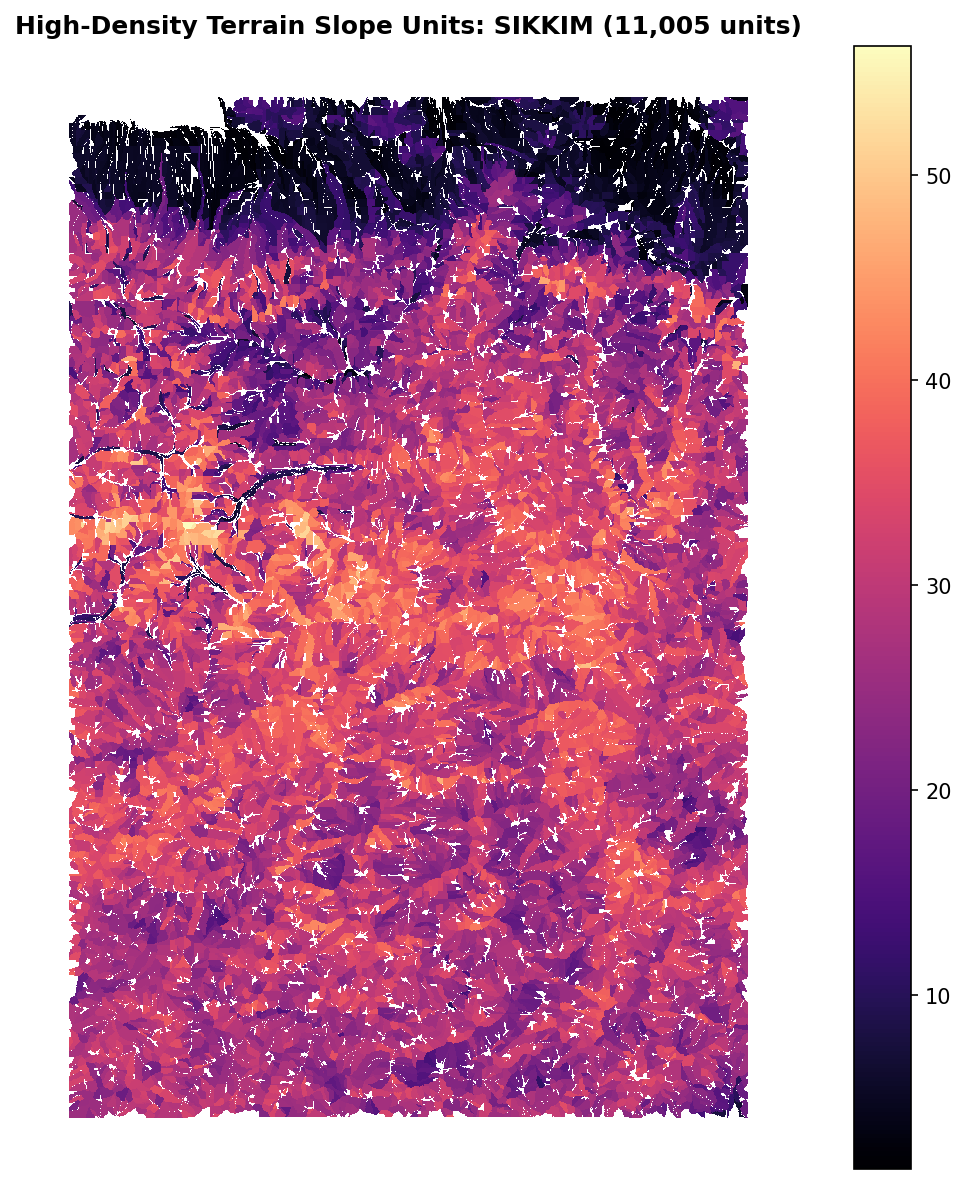

✅ High-Density Terrain Segmentation Verified!


In [26]:
# ── STEP 12: Render High-Resolution Continuous Susceptibility Heatmap ───────
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

print('📊 Visualizing High-Resolution Dense Slope-Unit Heatmap...')
if os.path.exists(OUT_PATH):
    gdf_check = gpd.read_file(OUT_PATH)
    print(f'Total Slope Units: {len(gdf_check):,} | Regions: {list(gdf_check.region.unique())}')

    # Plot first state (e.g. Sikkim or Cherrapunji)
    sample_reg = 'sikkim' if 'sikkim' in gdf_check.region.values else gdf_check.region.iloc[0]
    sub = gdf_check[gdf_check.region == sample_reg]

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    sub.plot(column='slope_degrees', cmap='magma', legend=True, ax=ax, edgecolor='none')
    ax.set_title(f'High-Density Terrain Slope Units: {sample_reg.upper()} ({len(sub):,} units)', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('✅ High-Density Terrain Segmentation Verified!')
